In [31]:
%matplotlib inline
from wrapper import BasicEnvironmentRGB, DomainRandomization, RandomColorReplace
import gymnasium as gym
from gymnasium.wrappers import FrameStackObservation, TransformObservation, ResizeObservation
from matplotlib import pyplot as plt
from rltesting.torch_rl.utils import random_sample_single_env
from rltesting.torch_rl.buffers import ReplayBuffer
from rltesting.torch_rl.models import MLP
from fvd_models import Encoder, Decoder, HybridAEVAE, AEVAE
import numpy as np
import torch
import skdim
import os
from scipy.stats import entropy
from sklearn.cluster import MiniBatchKMeans
from torch.nn import functional as F

np.random.seed(42)
torch.manual_seed(0)
# gym.utils.seeding.np_random(0)

to_numpy = lambda x: x.cpu().detach().numpy()
framestack = 2
latent_dim = 512
obs_shape = 64
data_steps = 100000 # 20k
num_epochs = 50
steps_per_epoch = 200 # 200
env = gym.make('Acrobot-v1', render_mode="rgb_array")
env = BasicEnvironmentRGB(env)
# env = gym.make('Pendulum-v1', render_mode='rgb_array')
env = DomainRandomization(env, {"LINK_LENGTH_1": lambda: np.random.choice([0.5, 1.0, 1.5, 2.0]), "LINK_LENGTH_2": lambda: np.random.choice([0.5, 1.0, 1.5, 2.0])})
# env = DomainRandomization(env, {"g": (5.0, 20.0)})
env = ResizeObservation(env, (obs_shape, obs_shape))
env = FrameStackObservation(env, stack_size=framestack)
env = TransformObservation(env, lambda obs: np.transpose(obs, (1, 2, 0, 3)), observation_space=gym.spaces.Box(0, 255, (framestack, 3, obs_shape, obs_shape), dtype=np.uint8))
env = TransformObservation(env, lambda obs: np.reshape(obs, (obs_shape, obs_shape, 3 * framestack)), observation_space=gym.spaces.Box(0, 255, (obs_shape, obs_shape, 3 * framestack), dtype=np.uint8))
buffer_shapes = [(obs_shape, obs_shape, 3 * framestack), (), (), ()]
dtypes = [np.uint8, np.float32, np.float32, np.float32]
buffer = ReplayBuffer(buffer_shapes, dtypes, buffer_size=data_steps)

In [32]:
obs, _ = env.reset()

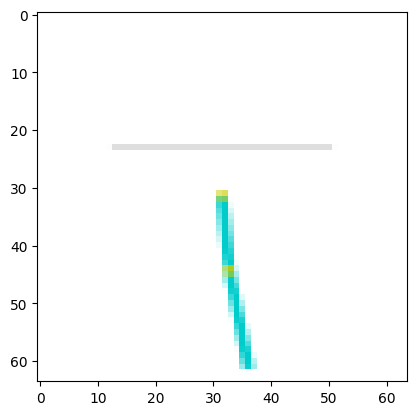

In [33]:
plt.imshow(obs[:, :, :3] / 255)

In [34]:
buffer_shapes = [(obs_shape, obs_shape, 3 * framestack), (), (), ()]
dtypes = [np.uint8, np.float32, np.float32, np.float32]
buffer = ReplayBuffer(buffer_shapes, dtypes, buffer_size=data_steps)
filepath = "hybrid_testing.npz"
if os.path.isfile(filepath):
  buffer.load(filepath)
else:
  samples = random_sample_single_env(env, num_steps=data_steps)
  for i in range(data_steps):
      buffer.add_sample([samples[j][i] for j in range(len(samples))].copy())
  buffer.save(filepath=filepath)

In [5]:
encoder = Encoder(framestack, latent_dim, obs_shape).cuda()
decoder = Decoder(encoder.conv_dim, framestack, latent_dim).cuda()
opt = torch.optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), 3e-4)
scheduler = torch.optim.lr_scheduler.ExponentialLR(opt, gamma=0.97)

In [ ]:
losses = []
for i in range(1, num_epochs + 1):
    for _ in range(steps_per_epoch):
        samples = buffer.sample(512)
        obs = (torch.tensor(samples[0]).float().transpose(-3, -1) / 255).cuda()
        latent = encoder(obs)
        reconstruction = decoder(latent)
        loss = torch.nn.functional.mse_loss(reconstruction, obs)
        loss.backward()
        opt.step()
        opt.zero_grad()
        losses.append(loss.detach().cpu().numpy())
    scheduler.step()
    if i % 10 == 0:
        print(i * steps_per_epoch)

2000
4000
6000
8000
10000


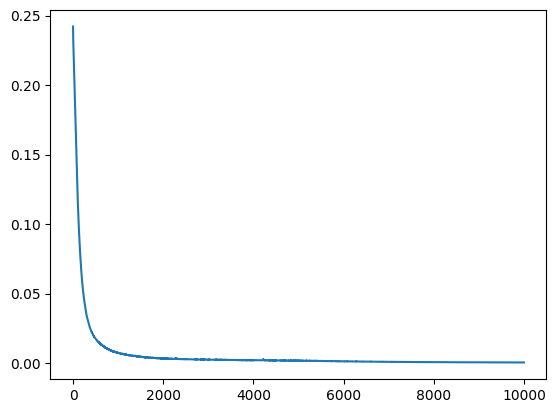

In [7]:
plt.plot(losses)


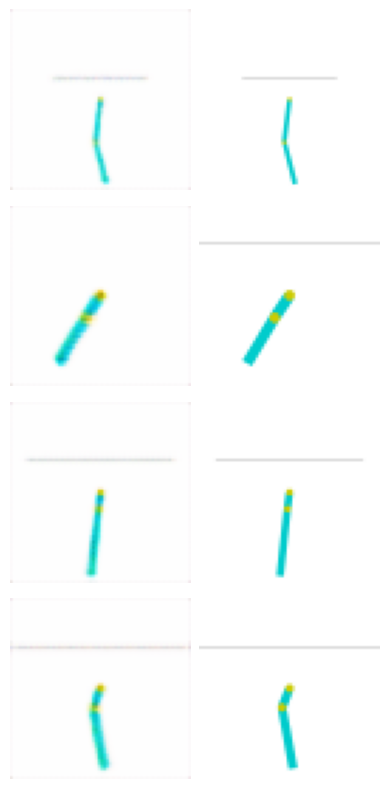

In [8]:
num_img = 4
fig, axs = plt.subplots(nrows=num_img, ncols=2, figsize=(4, 2 * num_img))
for i in range(4):
    axs[i][0].imshow(reconstruction[i].detach().cpu().transpose(-3, -1).numpy()[:, :, :3])
    axs[i][0].axis("off")
    axs[i][1].imshow(samples[0][i][:, :, :3])
    axs[i][1].axis("off")
plt.tight_layout()
plt.show()
fig.savefig("direct_dim.png")

In [9]:
latent_ID = []
image_ID = []

for _ in range(20):
    samples = buffer.sample(2048)
    obs = (torch.tensor(samples[0]).float().transpose(-3, -1) / 255).cuda()
    latent = encoder(obs)
    unique_latents = np.unique(latent.detach().cpu().numpy(), axis=0)
    unique_obs = np.unique(obs.detach().cpu().numpy(), axis=0).reshape(-1, 3 * framestack*obs_shape*obs_shape)

    latent_ID.append(skdim.id.MLE().fit(unique_latents).dimension_)
    image_ID.append(skdim.id.MLE().fit(unique_obs).dimension_)

print(f"Latent ID: {np.mean(latent_ID)} +- {np.std(latent_ID)}")
print(f"Image ID: {np.mean(image_ID)} +- {np.std(image_ID)}")


Latent ID: 5.914151080242356 +- 0.07348196115489505
Image ID: 9.761983236574316 +- 0.10745794296736703


2000
4000
6000
8000
10000


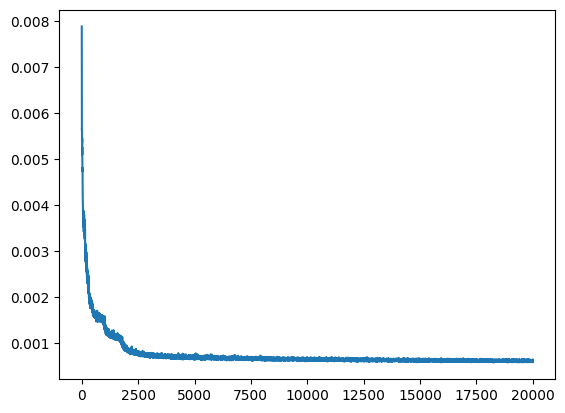

In [22]:
intrinsic_dim = round(np.mean(latent_ID))
double_autoencoder = AEVAE(encoder, decoder, latent_dim, intrinsic_dim, penalty_coef=1e-4).cuda()
int_opt = torch.optim.AdamW(double_autoencoder.parameters(), 3e-4)
int_scheduler = torch.optim.lr_scheduler.ExponentialLR(int_opt, gamma=0.97)
losses = []
for i in range(1, num_epochs + 1):
    for _ in range(2 * steps_per_epoch):
        samples = buffer.sample(512)
        obs = (torch.tensor(samples[0]).float().transpose(-3, -1) / 255).cuda()
        loss = double_autoencoder.reconstruction_loss(obs)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(double_autoencoder.parameters(), 1.0)
        int_opt.step()
        int_opt.zero_grad()
        losses.append(loss.detach().cpu().numpy())
    int_scheduler.step()
    if i % 10 == 0:
        print(i * steps_per_epoch)
plt.plot(losses)

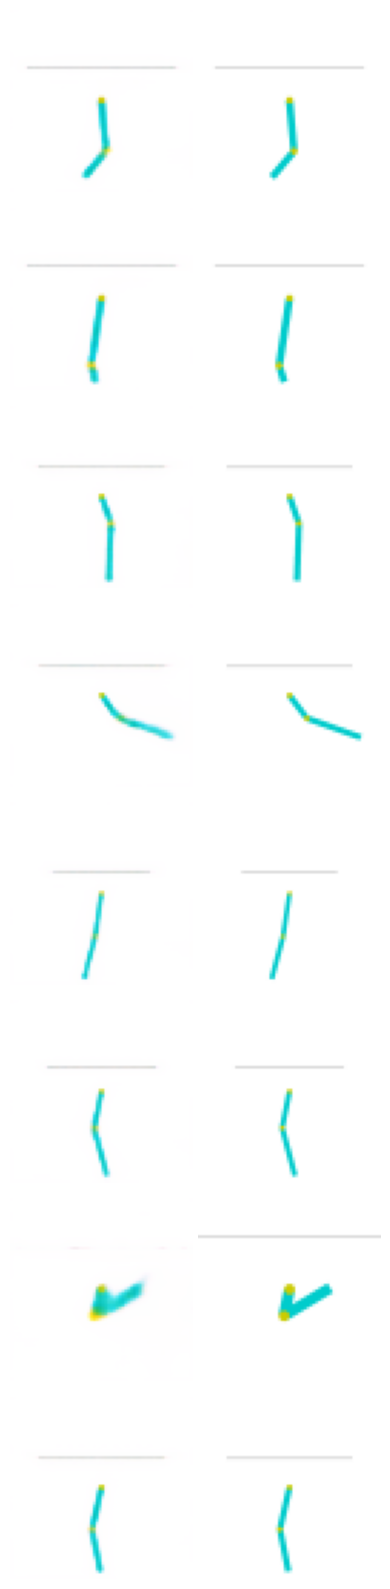

In [23]:
plt.close("all")
%matplotlib inline
num_img = 8
fig, axs = plt.subplots(nrows=num_img, ncols=2, figsize=(4, 2 * num_img))
int_latent = double_autoencoder.double_encode_deterministic(obs)
reconstruction = double_autoencoder.double_decode(int_latent)
for i in range(num_img):
    axs[i][0].imshow(reconstruction[i].detach().cpu().transpose(-3, -1).numpy()[:, :, :3])
    axs[i][0].axis("off")
    axs[i][1].imshow(samples[0][i][:, :, :3])
    axs[i][1].axis("off")
plt.tight_layout()
plt.show()

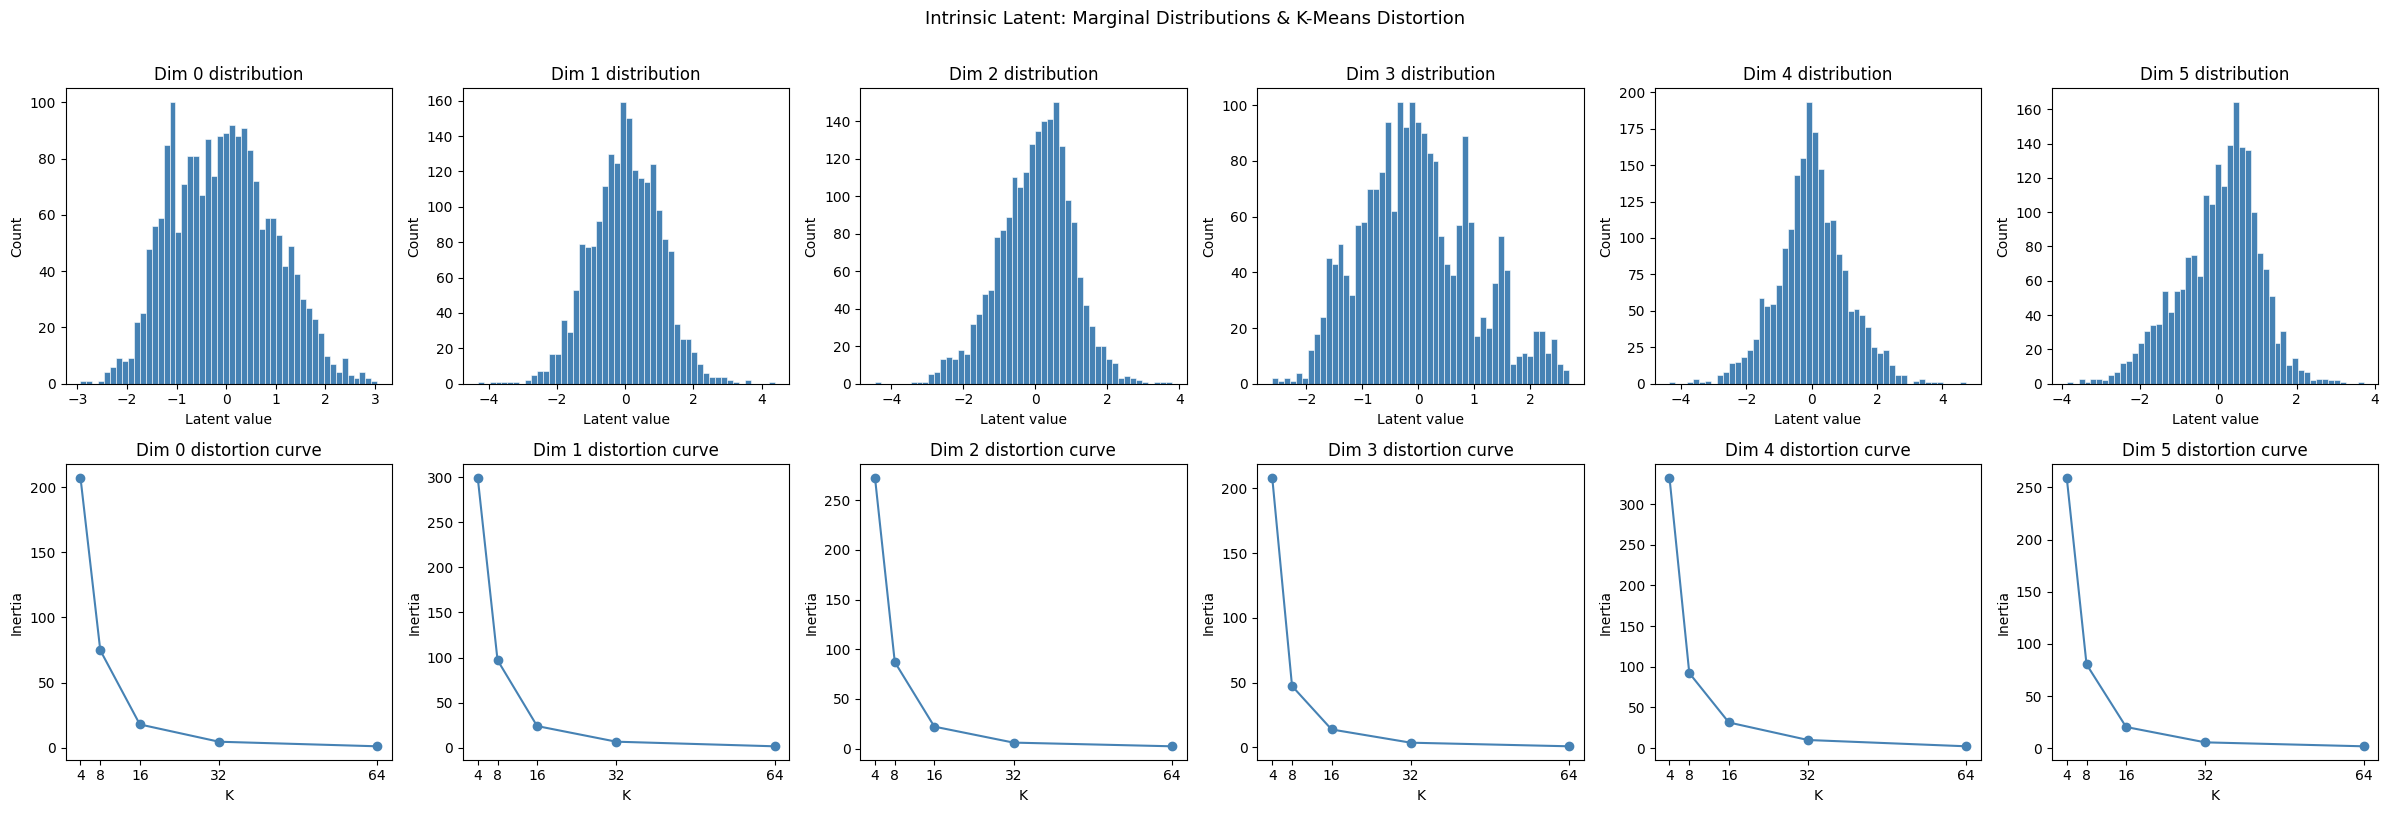

In [24]:
samples = buffer.sample(2048)
obs = (torch.tensor(samples[0]).float().transpose(-3, -1) / 255).cuda()
Z_intrinsic = to_numpy(double_autoencoder.double_encode_deterministic(obs))

k_values = [4, 8, 16, 32, 64]
fig, axes = plt.subplots(2, intrinsic_dim, figsize=(4 * intrinsic_dim, 8))

# If intrinsic_dim == 1, axes won't be 2D — normalize shape
if intrinsic_dim == 1:
    axes = axes.reshape(2, 1)

for i in range(intrinsic_dim):
    # Row 0: marginal histogram
    axes[0, i].hist(Z_intrinsic[:, i], bins=50, color='steelblue', edgecolor='white', linewidth=0.4)
    axes[0, i].set_title(f"Dim {i} distribution")
    axes[0, i].set_xlabel("Latent value")
    axes[0, i].set_ylabel("Count")

    # Row 1: distortion curve
    distortions = []
    for k in k_values:
        kmeans = MiniBatchKMeans(n_clusters=k, random_state=0).fit(Z_intrinsic[:, [i]])
        distortions.append(kmeans.inertia_)

    axes[1, i].plot(k_values, distortions, marker='o', color='steelblue')
    axes[1, i].set_title(f"Dim {i} distortion curve")
    axes[1, i].set_xlabel("K")
    axes[1, i].set_ylabel("Inertia")
    axes[1, i].set_xticks(k_values)

fig.suptitle("Intrinsic Latent: Marginal Distributions & K-Means Distortion", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("intrinsic_latent_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

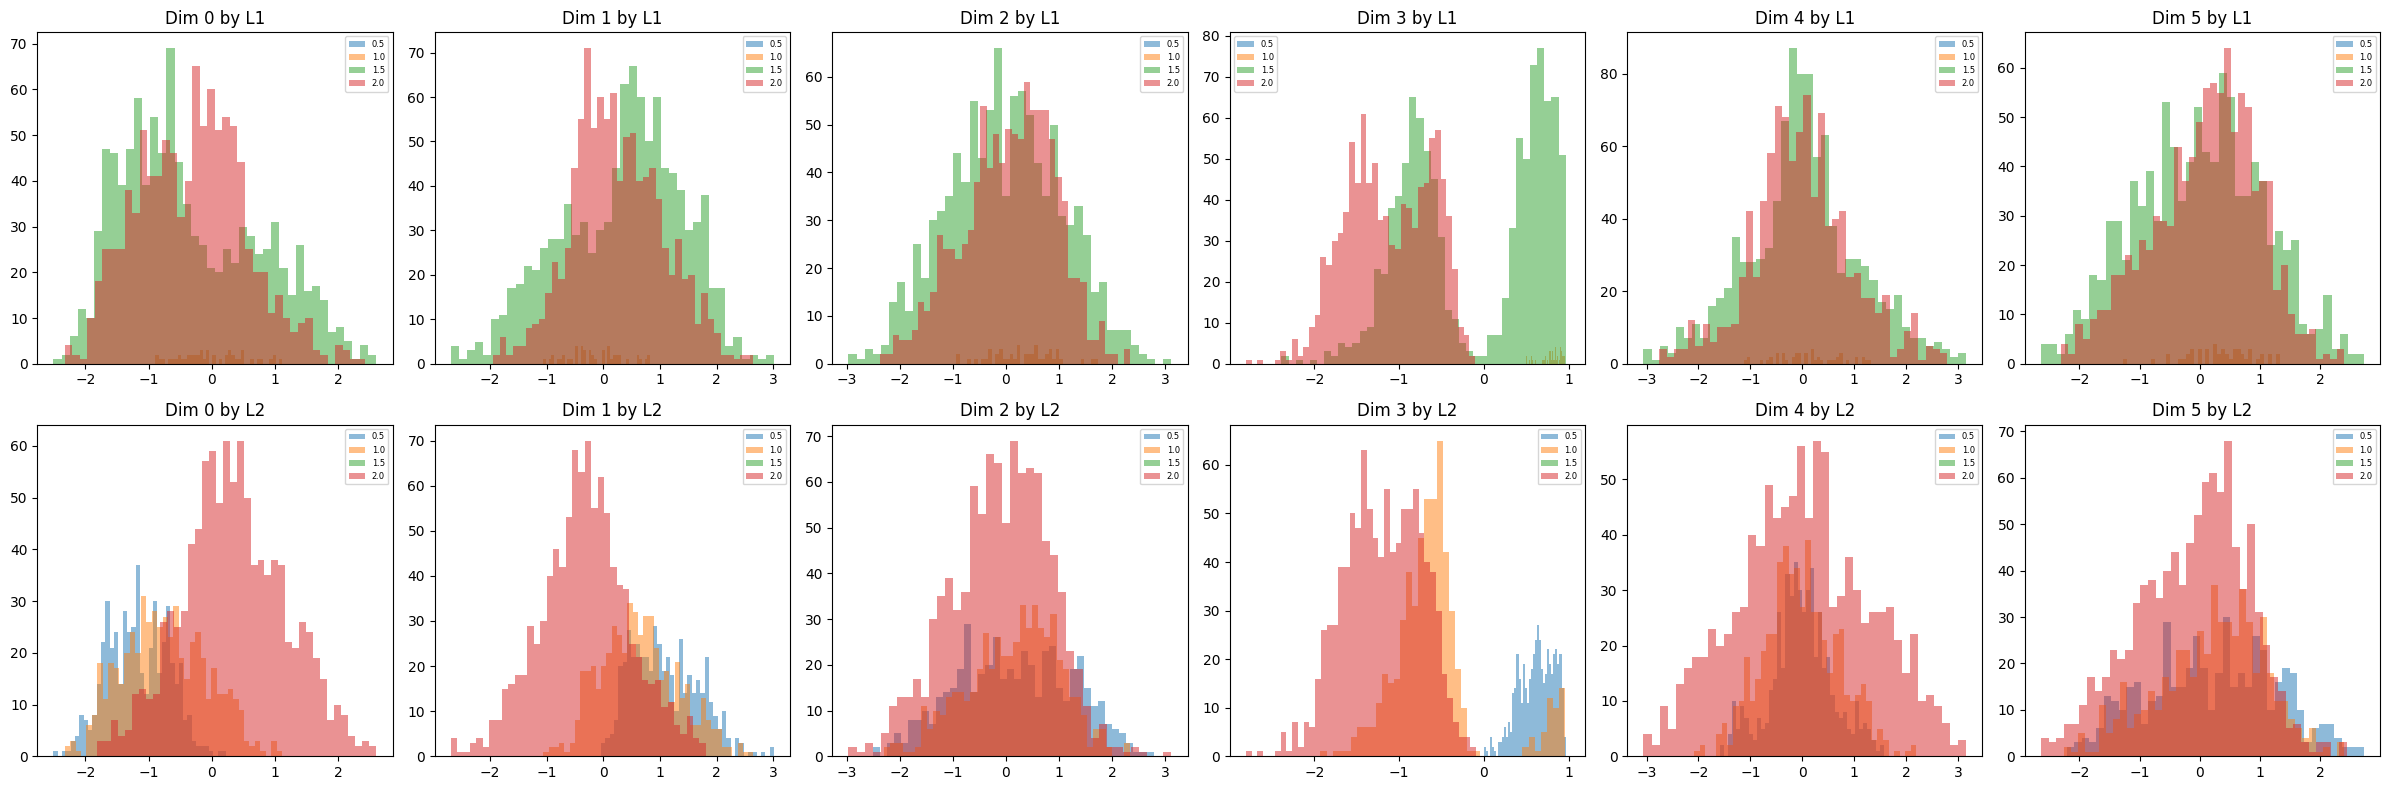

In [25]:
# One-off collection that also grabs link lengths
obs, _ = env.reset()
link_length_labels = []
obs_list = []

for _ in range(2048):
    action = env.action_space.sample()
    next_obs, reward, terminated, truncated, _ = env.step(action)
    
    obs_list.append(obs)
    link_length_labels.append([
        env.unwrapped.LINK_LENGTH_1, 
        env.unwrapped.LINK_LENGTH_2
    ])
    
    if terminated or truncated:
        obs, _ = env.reset()
    else:
        obs = next_obs

obs_tensor = (torch.tensor(np.array(obs_list)).float().transpose(-3, -1) / 255).cuda()
Z_intrinsic = to_numpy(double_autoencoder.double_encode_deterministic(obs_tensor))
link_length_labels = np.array(link_length_labels)

l1_values = [0.5, 1.0, 1.5, 2.0]
l2_values = [0.5, 1.0, 1.5, 2.0]

fig, axes = plt.subplots(2, intrinsic_dim, figsize=(4 * intrinsic_dim, 8))

for i in range(intrinsic_dim):
    for j, (link_vals, labels, name) in enumerate(zip(
        [l1_values, l2_values],
        [link_length_labels[:, 0], link_length_labels[:, 1]],
        ["L1", "L2"]
    )):
        for val in link_vals:
            mask = labels == val
            axes[j, i].hist(Z_intrinsic[mask, i], bins=40, alpha=0.5, label=f"{val}")
        axes[j, i].set_title(f"Dim {i} by {name}")
        axes[j, i].legend(fontsize=6)

plt.tight_layout()
plt.show()

Continuous vs original:  0.000257
Quantized  vs original:  0.002099
Quantized  vs continuous: 0.001778  (quantization-only cost)


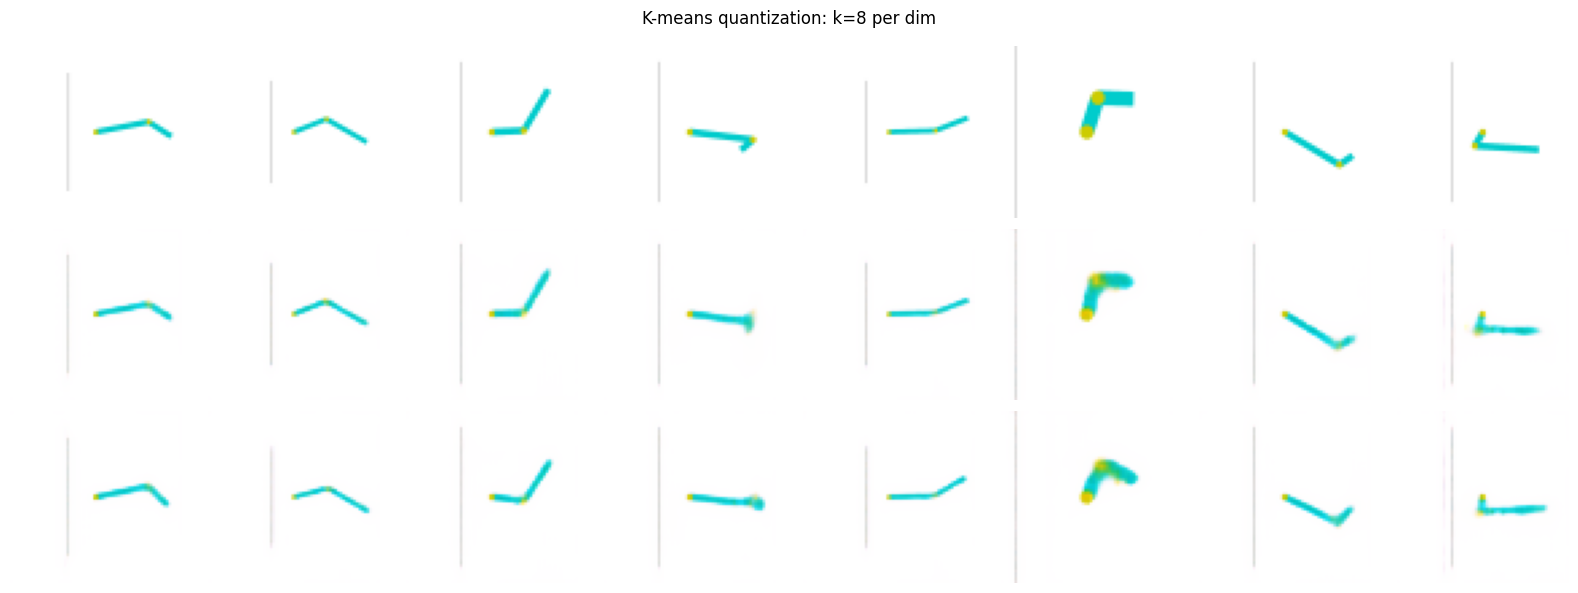

In [40]:
# ── Cell 13 (fixed) ── Quantization reconstruction quality test ──

# Sample from buffer and encode fresh — keeps obs and Z_intrinsic in sync
samples = buffer.sample(2048)
obs = (torch.tensor(samples[0]).float().transpose(-3, -1) / 255).cuda()

with torch.no_grad():
    Z_intrinsic = to_numpy(double_autoencoder.double_encode_deterministic(obs))

# Fit k-means per dimension
k_per_dim = [8, 8, 8, 8, 8, 8]  # adjust based on distortion curves
kmeans_list = [
    MiniBatchKMeans(n_clusters=k, random_state=0).fit(Z_intrinsic[:, [i]])
    for i, k in enumerate(k_per_dim)
]

# Quantize — replace each value with its nearest centroid
Z_quantized = np.stack([
    kmeans_list[i].cluster_centers_[kmeans_list[i].predict(Z_intrinsic[:, [i]])].squeeze()
    for i in range(intrinsic_dim)
], axis=1)

Z_tensor = torch.tensor(Z_intrinsic, dtype=torch.float32).cuda()
Z_q_tensor = torch.tensor(Z_quantized, dtype=torch.float32).cuda()

with torch.no_grad():
    recon_continuous = double_autoencoder.double_decode(Z_tensor)
    recon_quantized = double_autoencoder.double_decode(Z_q_tensor)

# MSE: quantized vs continuous (how much does binning hurt relative to continuous?)
mse_quant_vs_cont = F.mse_loss(recon_quantized, recon_continuous).item()
# MSE: continuous vs original (baseline reconstruction quality)
mse_cont_vs_orig = F.mse_loss(recon_continuous, obs).item()
# MSE: quantized vs original (total degradation)
mse_quant_vs_orig = F.mse_loss(recon_quantized, obs).item()

print(f"Continuous vs original:  {mse_cont_vs_orig:.6f}")
print(f"Quantized  vs original:  {mse_quant_vs_orig:.6f}")
print(f"Quantized  vs continuous: {mse_quant_vs_cont:.6f}  (quantization-only cost)")

# ── Visual comparison ──
n_show = 8
fig, axes = plt.subplots(3, n_show, figsize=(2 * n_show, 6))

# Convert to (B, H, W, C) for imshow — use permute for torch tensors
obs_np = to_numpy(obs.permute(0, 2, 3, 1))
recon_cont_np = to_numpy(recon_continuous.permute(0, 2, 3, 1))
recon_quant_np = to_numpy(recon_quantized.permute(0, 2, 3, 1))

for j in range(n_show):
    axes[0, j].imshow(obs_np[j, :, :, :3])
    axes[1, j].imshow(recon_cont_np[j, :, :, :3])
    axes[2, j].imshow(recon_quant_np[j, :, :, :3])
    for row in range(3):
        axes[row, j].axis('off')

axes[0, 0].set_ylabel("Original", fontsize=10)
axes[1, 0].set_ylabel("Continuous", fontsize=10)
axes[2, 0].set_ylabel("Quantized", fontsize=10)
fig.suptitle(f"K-means quantization: k={k_per_dim[0]} per dim", fontsize=12)
plt.tight_layout()
plt.show()